# Medical Cost Analysis: Insurance Price Prediction 🩺💰

## 1. Project Overview & Objective 🔎

"The goal of this project is to predict annual medical insurance costs based on individual health and demographic data (age, BMI, smoking status, etc.). By utilizing a Linear Regression model, we aim to identify which factors contribute most significantly to insurance charges and build a reliable prediction system."

## 2. Dataset Summary & Data Loading 📁
The dataset was structurally analyzed before proceeding to the modeling process. It consists of a total of **1338 observations** and **7 columns**. Our target variable, `charges`, is a continuous numerical value.

| Feature Name | Data Type | Description | Variable Type |
| :--- | :--- | :--- | :--- |
| **Age** | Integer | Person's Age | Numerical |
| **Sex** | Object | Gender (female, male) | Categorical |
| **BMI** | Float | Body mass index | Numerical |
| **Children** | Integer | Number of children | Numerical |
| **Smoker** | Object | Smoking status | Categorical (Binary) |
| **Region** | Object | Region in the US | Categorical |
| **Charges** | Float | **Target Variable** | Numerical (Continuous) |

**Analysis Note:** The categorical variables (`Sex`, `Smoker`, `Region`) will be converted into numerical form using **Label Encoding** and **One-Hot Encoding** methods in the following steps so that the Linear Regression model can be processed mathematically.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/insurance/insurance.csv


In [2]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

## 3. Exploratory Data Analysis 🎯

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


#### Statistical Breakdowns 📈

In [9]:
df.groupby("region")["charges"].mean()

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [10]:
df.groupby("sex")["charges"].mean()

sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64

In [11]:
df.groupby("children")["charges"].mean()

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

In [12]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Independent Variable

In [13]:
df.groupby("region")["bmi"].mean()

region
northeast    29.173503
northwest    29.199785
southeast    33.355989
southwest    30.596615
Name: bmi, dtype: float64

In [14]:
df.groupby("sex")["bmi"].mean()

sex
female    30.377749
male      30.943129
Name: bmi, dtype: float64

In [15]:
df.groupby("smoker")["bmi"].mean()

smoker
no     30.651795
yes    30.708449
Name: bmi, dtype: float64

##  4. Visualization - Descriptive Insights 🎨
    1. Target Variable Distribution (charges)
"The distribution of charges is right-skewed, indicating that most individuals have lower medical costs, while a smaller group incurs very high expenses. This suggests that the model might face challenges in predicting extreme high-cost cases."

    2. Age vs. Charges by Smoking Status
"This scatter plot illustrates a clear linear relationship between age and charges. However, the most striking insight is the separation caused by smoking. Smokers (represented in a different color) pay significantly higher premiums across all age groups compared to non-smokers."

    3. BMI vs. Charges by Smoking Status
"While bmi generally increases medical costs, its impact is exponentially higher for smokers. Non-smokers with high BMI values maintain relatively stable costs, whereas smokers with high BMI (especially over 30) fall into the highest cost bracket."

    4. Categorical Breakdowns (Sex, Region, Children)
* By Region: "The average cost analysis shows that the Southeast region has the highest medical expenses, while the Southwest and Northwest regions are more cost-effective."

* By Children: "This visualization examines whether family size impacts insurance premiums. We observe a slight increase in variance as the number of children increases, though it is less dominant than smoking or age."

    🔍 Correlation Matrix (Heatmap)
"The heatmap provides a mathematical summary of feature relationships.

* Smoker (0.79): The strongest positive correlation with charges.

* Age (0.30): A moderate positive correlation, reflecting the natural increase in health risks over time.

* BMI (0.20): Shows a positive but weaker direct correlation compared to smoking."

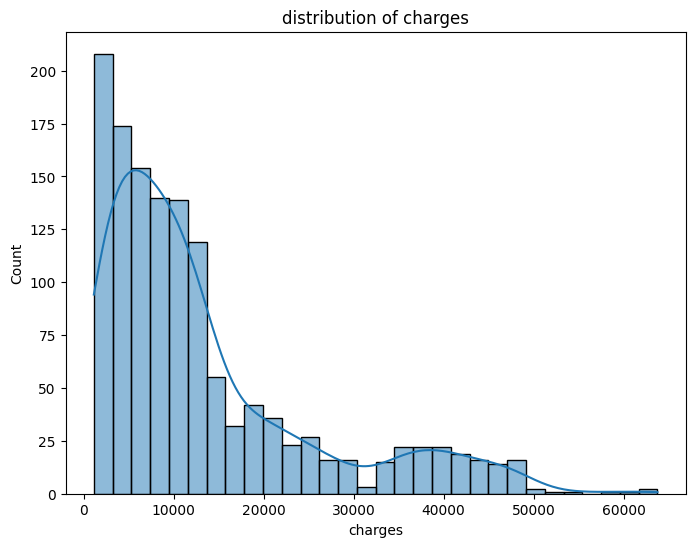

In [16]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="charges", kde = True)
plt.title("distribution of charges")
plt.show()

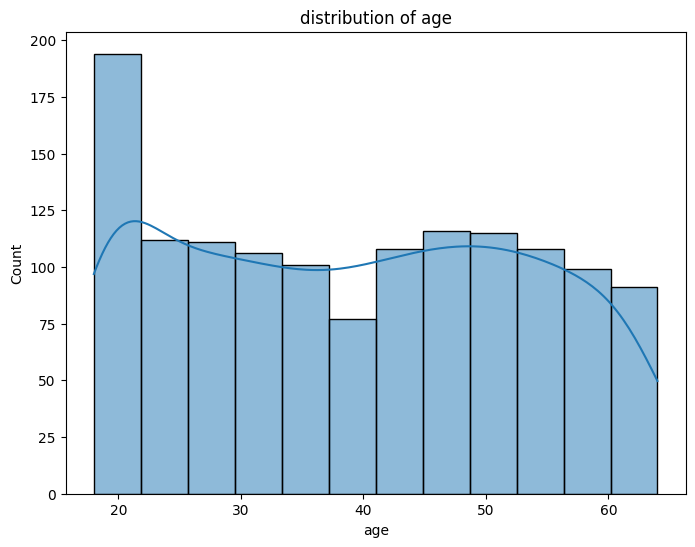

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="age", kde = True)
plt.title("distribution of age")
plt.show()

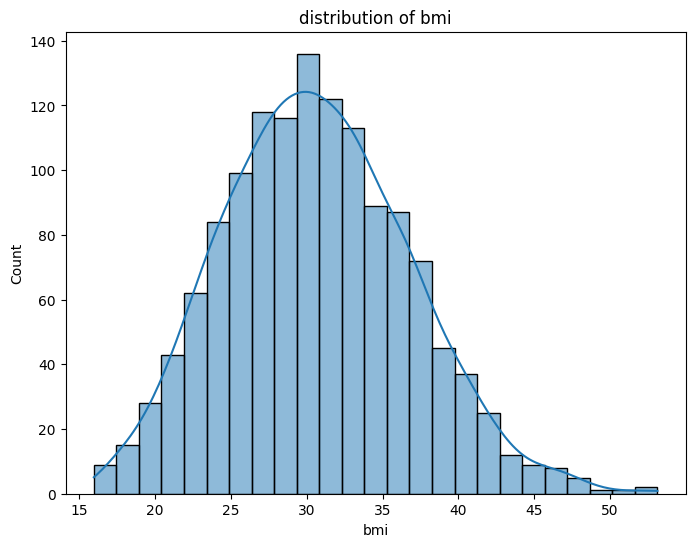

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="bmi", kde = True)
plt.title("distribution of bmi")
plt.show()

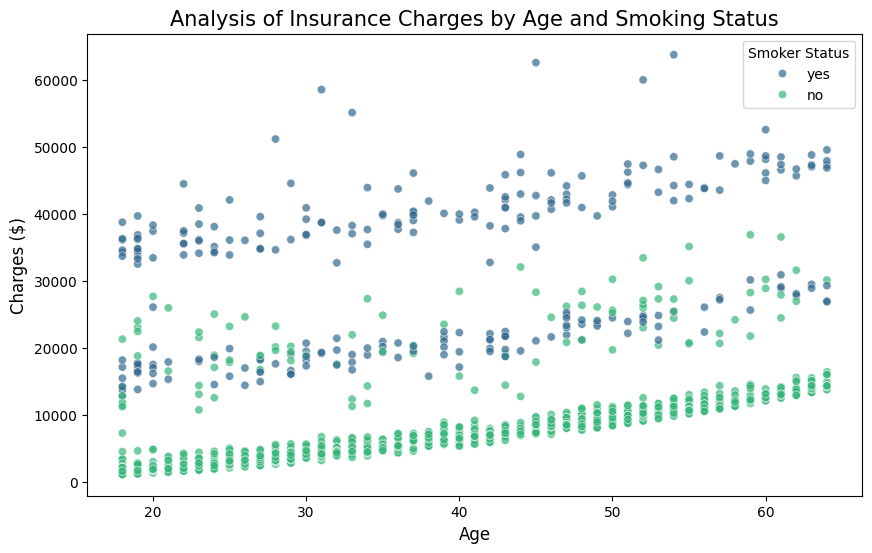

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', palette='viridis', alpha=0.7)
plt.title('Analysis of Insurance Charges by Age and Smoking Status', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(title='Smoker Status')
plt.show()

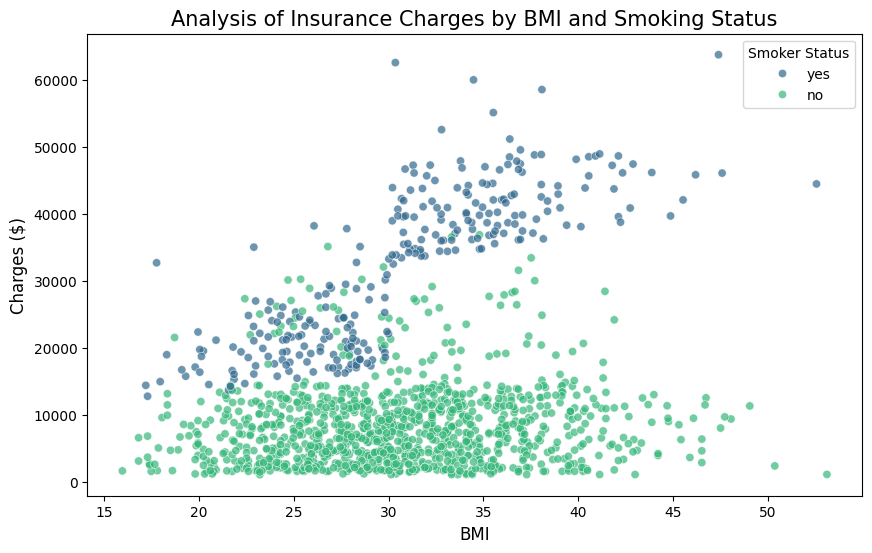

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', palette='viridis', alpha=0.7)
plt.title('Analysis of Insurance Charges by BMI and Smoking Status', fontsize=15)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(title='Smoker Status')
plt.show()

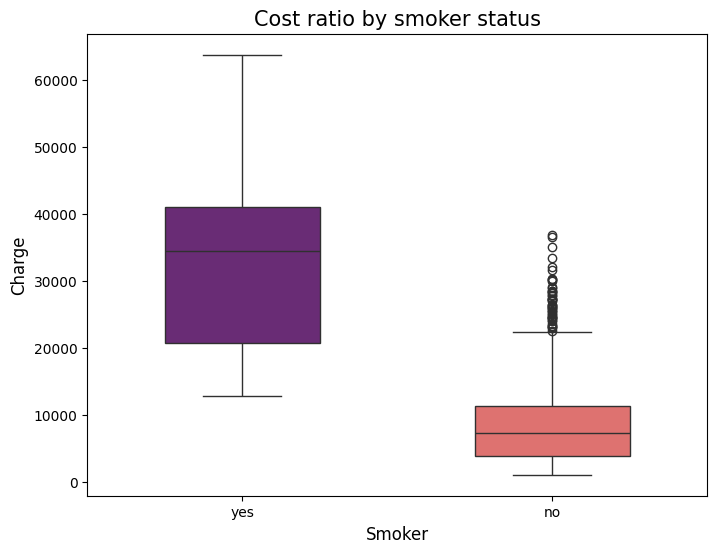

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(x='smoker', y='charges', data=df, palette='magma', width=0.5)
plt.title('Cost ratio by smoker status', fontsize=15)
plt.xlabel('Smoker', fontsize=12)
plt.ylabel('Charge', fontsize=12)
plt.show()

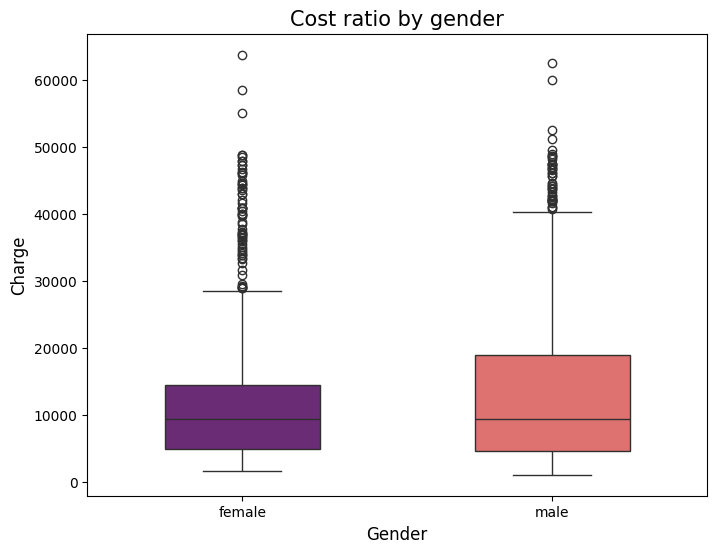

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='charges', data=df, palette='magma', width=0.5)
plt.title('Cost ratio by gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Charge', fontsize=12)
plt.show()

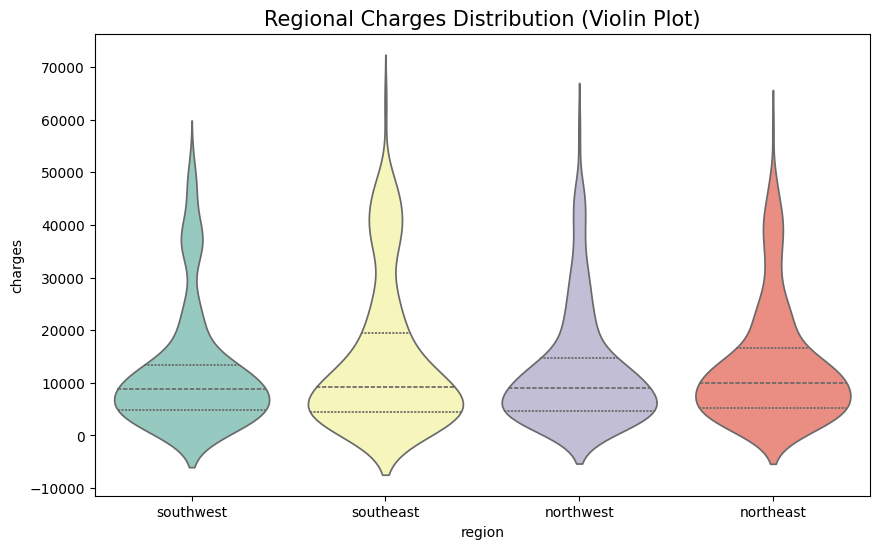

In [23]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='region', y='charges', data=df, palette='Set3', inner="quartile")
plt.title('Regional Charges Distribution (Violin Plot)', fontsize=15)
plt.show()

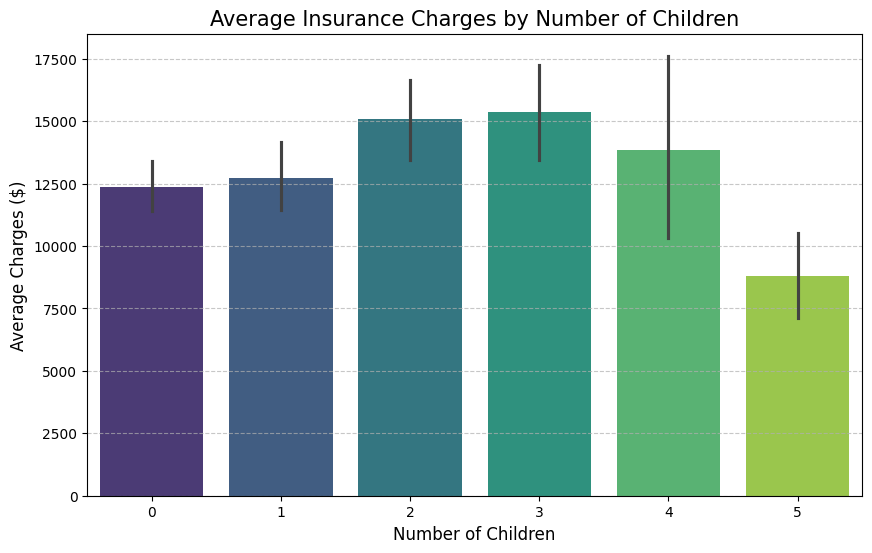

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='children', y='charges', data=df, palette='viridis', ci=95)
plt.title('Average Insurance Charges by Number of Children', fontsize=15)
plt.xlabel('Number of Children', fontsize=12)
plt.ylabel('Average Charges ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

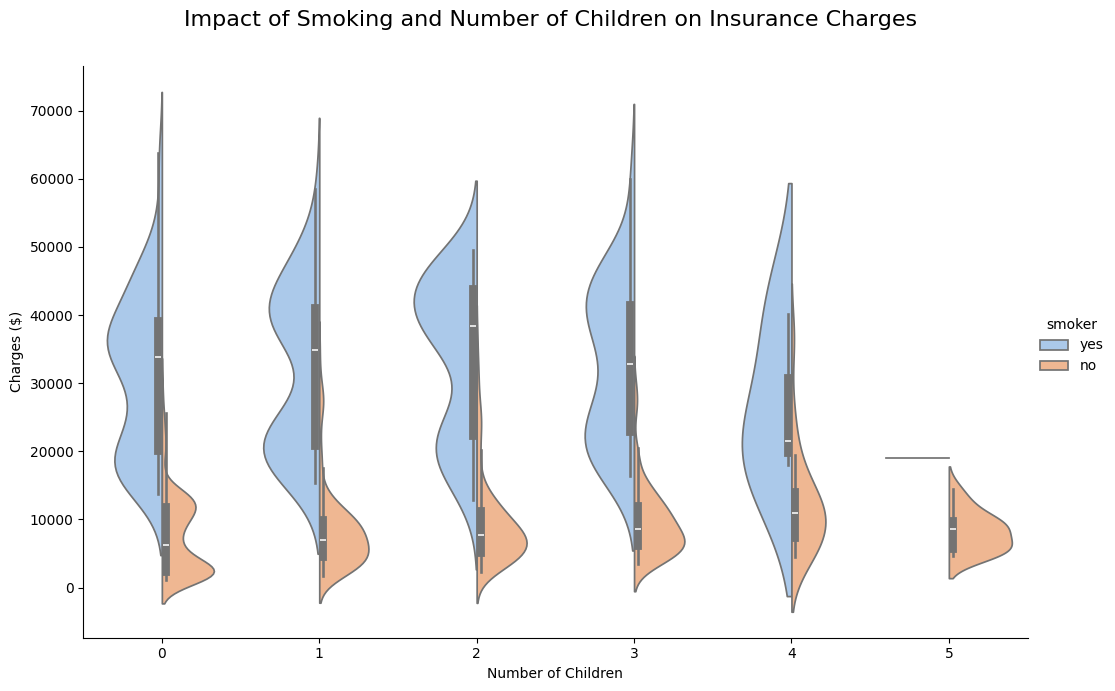

In [25]:
g = sns.catplot(x="children", y="charges", hue="smoker", 
                data=df, kind="violin", split=True,
                palette="pastel", height=7, aspect=1.5)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Impact of Smoking and Number of Children on Insurance Charges', fontsize=16)
g.set_axis_labels("Number of Children", "Charges ($)")
plt.show()

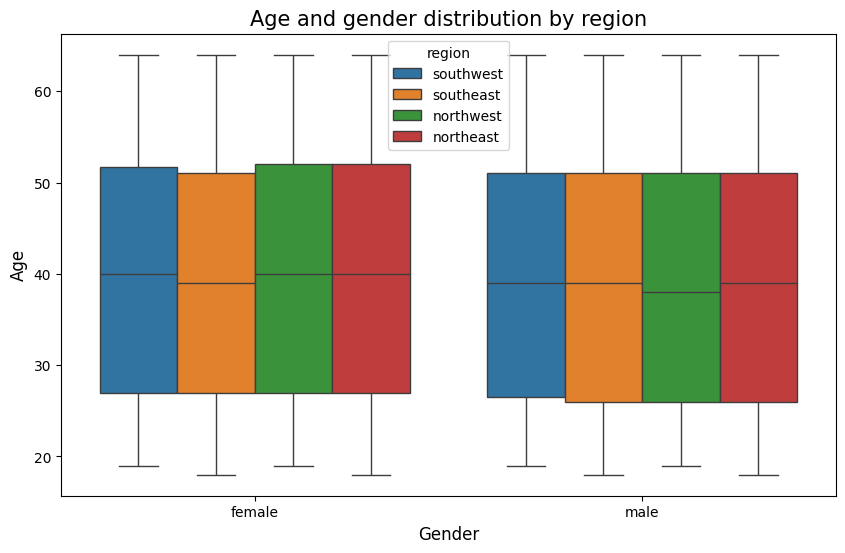

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="sex", y="age", hue="region")
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.title('Age and gender distribution by region', fontsize=15)
plt.show()

<Figure size 800x600 with 0 Axes>

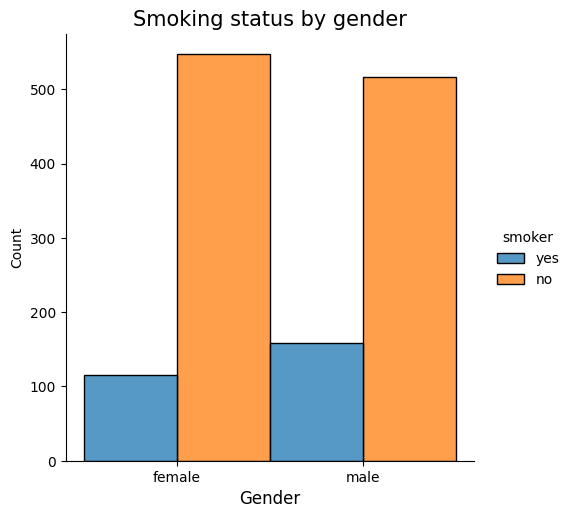

In [27]:
plt.figure(figsize=(8,6))
sns.displot(data = df, x = "sex", hue="smoker", multiple="dodge")
plt.title('Smoking status by gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.show()

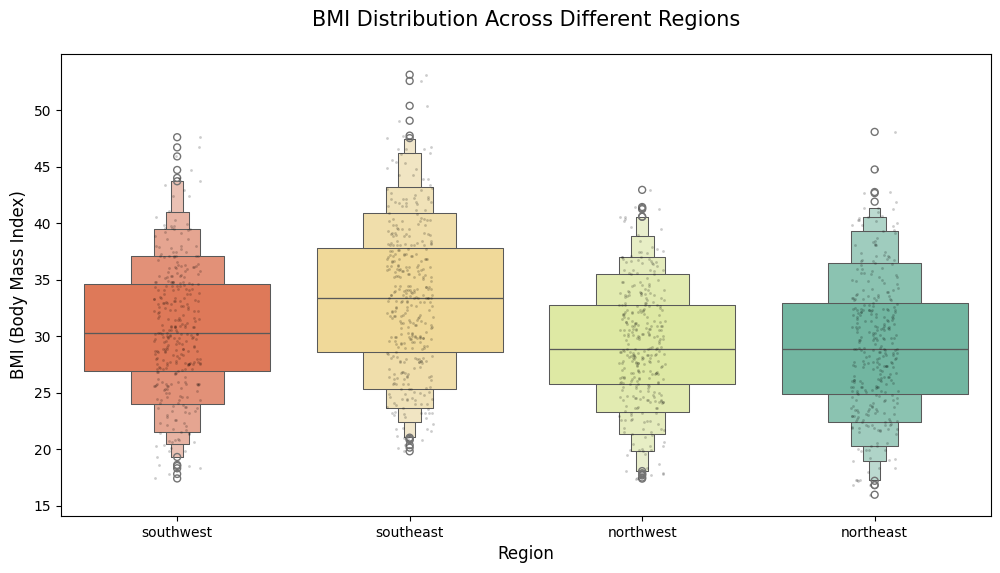

In [28]:
plt.figure(figsize=(12, 6))
sns.boxenplot(x='region', y='bmi', data=df, palette='Spectral')
sns.stripplot(x='region', y='bmi', data=df, color="black", size=2, alpha=0.2)
plt.title('BMI Distribution Across Different Regions', fontsize=15, pad=20)
plt.xlabel('Region', fontsize=12)
plt.ylabel('BMI (Body Mass Index)', fontsize=12)
plt.show()

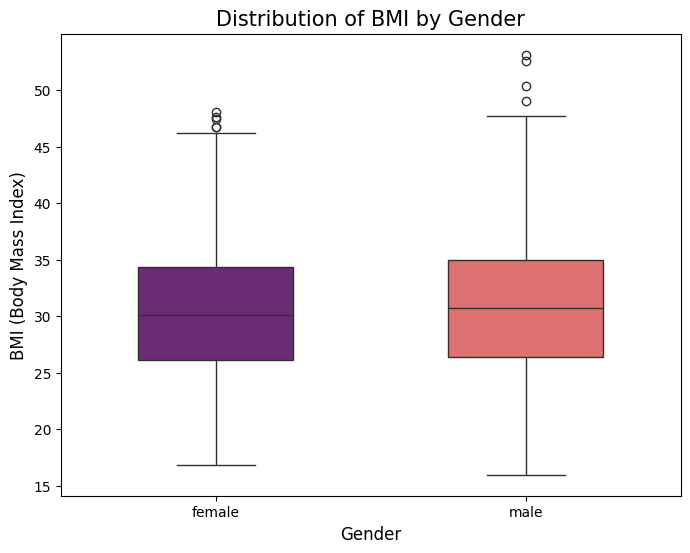

In [29]:
plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='bmi', data=df, palette='magma', width=0.5)
plt.title('Distribution of BMI by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('BMI (Body Mass Index)', fontsize=12)
plt.show()

<Figure size 800x600 with 0 Axes>

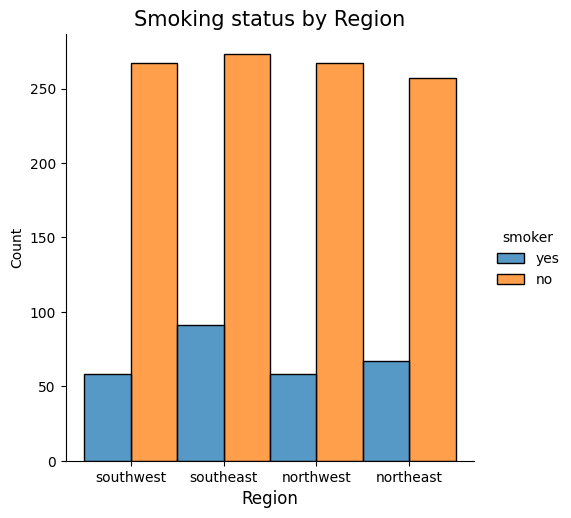

In [30]:
plt.figure(figsize=(8,6))
sns.displot(data = df, x = "region", hue="smoker", multiple="dodge")
plt.title('Smoking status by Region', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.show()

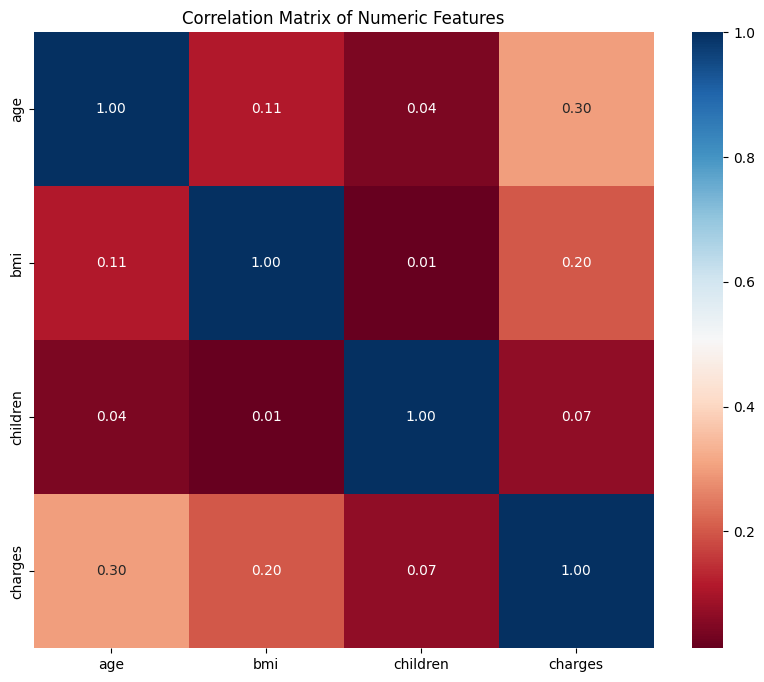

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

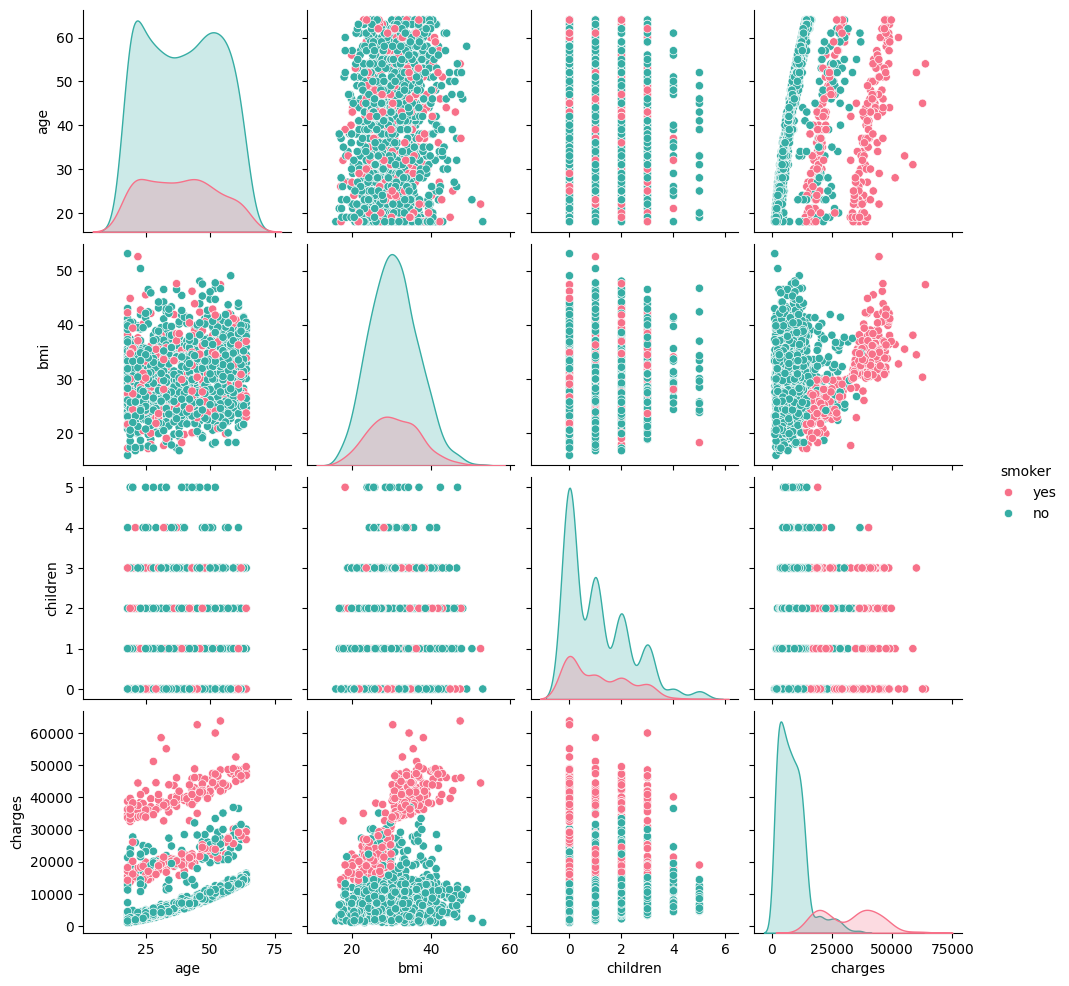

In [32]:
sns.pairplot(df, hue='smoker', palette='husl')
plt.show()

## 5. Summary of EDA Findings 📝
"Based on our visual exploration, we can conclude that smoking status, age, and BMI are the three primary drivers of medical insurance costs. Lifestyle choices (smoking) appear to be more influential than demographic factors like gender or geographic region. These insights will guide our feature selection for the Linear Regression model."

 ## 6. Data Preprocessing 🛠️
 
**"Machine learning models require numerical input. Therefore, we performed the following steps:**

* Encoding: Categorical variables like sex and smoker were converted using Label Encoding, while region was transformed via One-Hot Encoding.

* Train-Test Split: The data was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

* Scaling: We applied StandardScaler to normalize numerical features, ensuring that variables with different scales (e.g., age vs. BMI) are treated equally by the model."

In [33]:
# Label Encoding (For Binary Categories)
# Let's digitize gender and smoking status
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [35]:
# One-Hot Encoding (For Multiple Categories)
# Let's divide the regions into separate columns (Dummy variables)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# drop_first=True: Creates 3 columns instead of 4 regions,
# because if all 3 are 0, it's understood that there is already a 4th region. (Multicollinarity prevention)

In [36]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


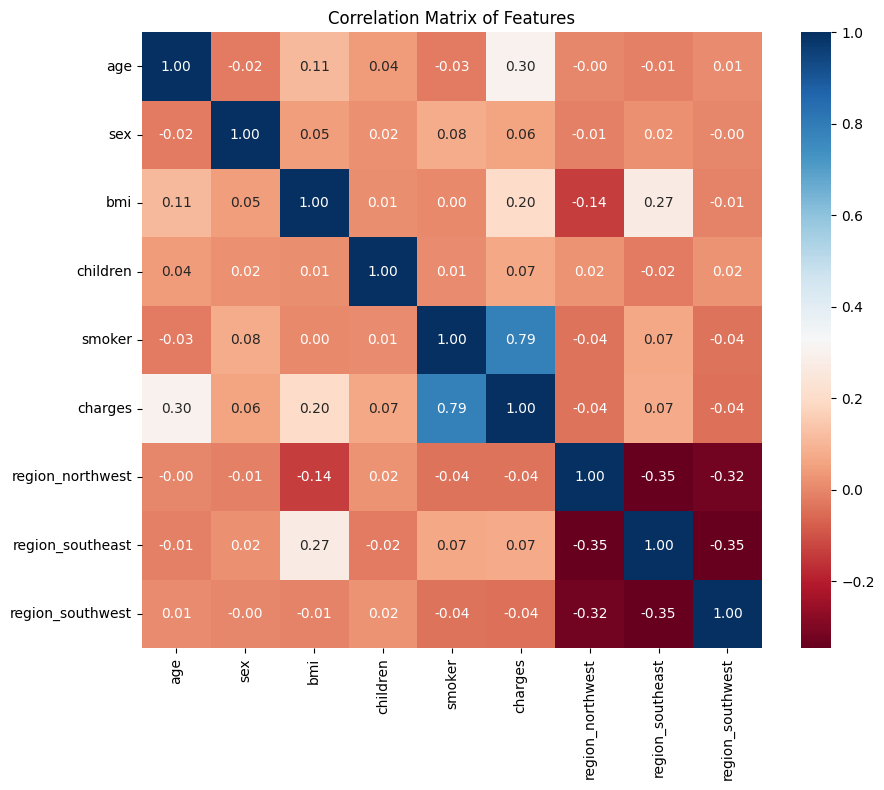

In [37]:
plt.figure(figsize=(10, 8))
# Draw the heat map by including only the numerical columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

## 7. Model Evaluation 🤖
"The model's performance was evaluated using R-Squared ($R^2$) and Root Mean Squared Error 
* (RMSE): R-Squared (0.78): Our model explains approximately 78% of the variance in medical charges.
* RMSE: On average, our predictions deviate by about $5,796 from the actual values.The 'Actual vs. Predicted' plot confirms that the model captures the general trend effectively, although some outliers exist at higher cost levels."

In [38]:
# independent & dependent variables

X = df.drop("charges", axis = 1)
y = df["charges"]

In [39]:
# train & test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [40]:
X_train.shape

(1070, 8)

In [41]:
X_test.shape

(268, 8)

In [42]:
scaler = StandardScaler()

In [43]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
X_train

array([[ 0.47222651, -1.0246016 , -1.75652513, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       [ 0.54331294, -1.0246016 , -1.03308239, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [ 0.8987451 , -1.0246016 , -0.94368672, ..., -0.56079971,
         1.66760869, -0.5723141 ],
       ...,
       [ 1.3252637 ,  0.97598911, -0.89153925, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [-0.16755139, -1.0246016 ,  2.82086429, ..., -0.56079971,
        -0.59966106,  1.74729228],
       [ 1.1120044 ,  0.97598911, -0.10932713, ..., -0.56079971,
        -0.59966106,  1.74729228]])

In [45]:
X_test

array([[ 0.40114007, -1.0246016 , -0.89153925, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [-0.23863782, -1.0246016 , -0.08946143, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       [ 1.75178229, -1.0246016 , -0.60845296, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       ...,
       [-0.09646495,  0.97598911, -0.41972876, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [ 1.04091797, -1.0246016 ,  2.78941026, ..., -0.56079971,
         1.66760869, -0.5723141 ],
       [ 0.82765867, -1.0246016 ,  0.60252728, ..., -0.56079971,
        -0.59966106,  1.74729228]])

In [46]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [47]:
y_pred = reg.predict(X_test)

In [48]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("mse: ", mse)
print("rmse: ", rmse)
print("r2 score: ", r2)

mse:  33596915.851361476
rmse:  5796.284659276274
r2 score:  0.7835929767120722


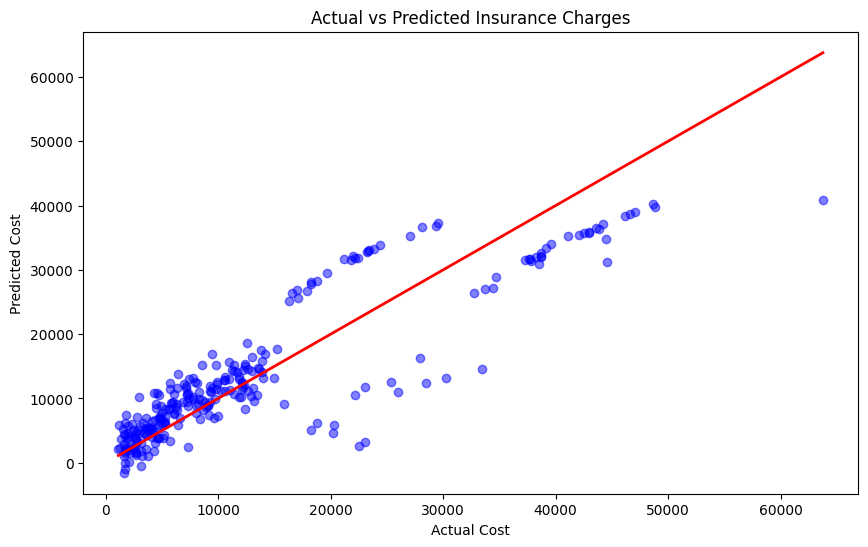

In [49]:
# Let's get predictions based on the test set.
y_pred = reg.predict(X_test)

plt.figure(figsize=(10, 6))

# Scatter plot comparing actual values and predictions
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

# Let's add the perfect prediction line (the y=x line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()

## 8. Feature Importance ✨
"Analyzing the model coefficients reveals that **smoking** is the most dominant predictor of insurance costs. It is followed by **age** and **BMI**. Interestingly, geographical region has the least impact on the final prediction, suggesting that lifestyle and biological factors are more critical than location."

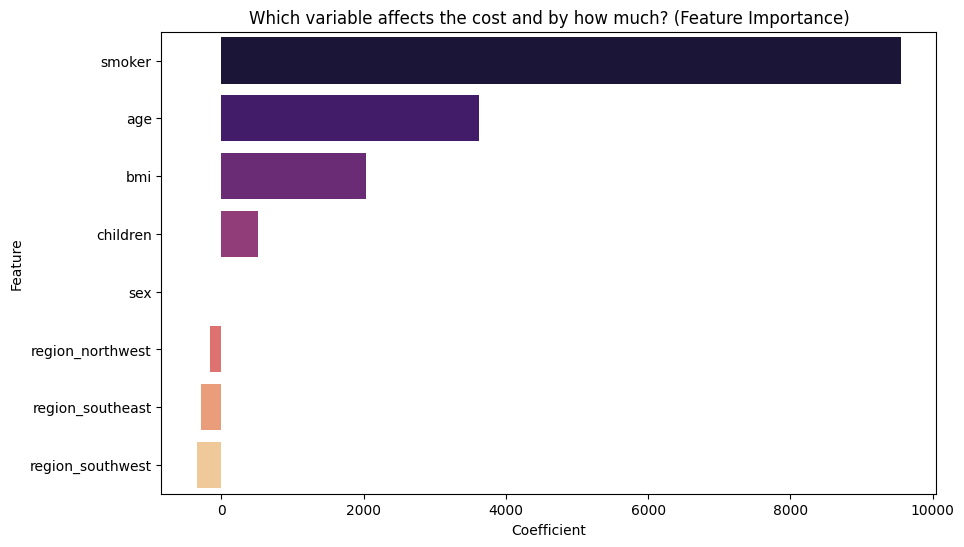

In [50]:
# Let's get the model coefficients
# Note: If you have scaled the data (StandardScaler), the coefficients are comparable.
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': reg.coef_
})

# Let's rank them according to importance.
importance = importance.sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='magma')
plt.title('Which variable affects the cost and by how much? (Feature Importance)')
plt.xlabel('Coefficient')
plt.show()

### 💡 How the Prediction Engine Works
1. **Raw Input:** The function accepts human-readable strings like "male" or "southeast".
2. **Transformation:** It converts these strings into the binary and dummy variables that the **Linear Regression** model expects.
3. **Consistency:** It uses the same `scaler` (StandardScaler) instance from our training pipeline to ensure the age and BMI values are normalized correctly before prediction.
4. **Output:** It returns a dollar-denominated prediction for the annual medical insurance cost.

In [51]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    """
    Predicts the insurance cost based on raw user input.
    
    Parameters:
    age (int): Age of the individual
    sex (str): 'female' or 'male'
    bmi (float): Body Mass Index
    children (int): Number of children/dependents
    smoker (str): 'yes' or 'no'
    region (str): 'northeast', 'northwest', 'southeast', 'southwest'
    
    Returns:
    float: Predicted insurance charge
    """
    
    # 1. Encoding Categorical Variables
    # Binary encoding for sex and smoker status
    sex_val = 1 if sex.lower() == 'male' else 0
    smoker_val = 1 if smoker.lower() == 'yes' else 0
    
    # One-Hot Encoding logic for Region (matching X_train column order)
    # Order: [age, sex, bmi, children, smoker, region_northwest, region_southeast, region_southwest]
    reg_nw = 1 if region.lower() == 'northwest' else 0
    reg_se = 1 if region.lower() == 'southeast' else 0
    reg_sw = 1 if region.lower() == 'southwest' else 0
    
    # 2. Reshaping data for the model
    input_features = np.array([[age, sex_val, bmi, children, smoker_val, reg_nw, reg_se, reg_sw]])
    
    # 3. Feature Scaling
    # Applying the same transformation used on the training set
    input_scaled = scaler.transform(input_features)
    
    # 4. Model Prediction
    prediction = reg.predict(input_scaled)
    
    return prediction[0]

# --- Example Usage / Test Case ---
test_age = 30
test_sex = 'male'
test_bmi = 28.5
test_children = 2
test_smoker = 'yes'
test_region = 'southeast'

predicted_price = predict_insurance_cost(test_age, test_sex, test_bmi, test_children, test_smoker, test_region)

print(f"--- Individual Insurance Prediction ---")
print(f"Predicted Annual Charge: ${predicted_price:.2f}")

--- Individual Insurance Prediction ---
Predicted Annual Charge: $29210.42


## 9. Conclusion 🏁
This end-to-end machine learning project successfully demonstrates:
* The overwhelming impact of **lifestyle choices (smoking)** on healthcare costs.
* The reliability of **Linear Regression** for predicting insurance premiums with a solid $R^2$ score.
* The necessity of **proper data scaling** and **encoding** for accurate coefficient interpretation.

**Future Improvements:**
To further reduce the error (RMSE), more complex algorithms like **Random Forest** or **Gradient Boosting (XGBoost)** could be explored to capture non-linear relationships.